# **Importing Libraries**

In [39]:
# Import required libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers
from tensorflow.keras.applications.efficientnet import preprocess_input

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Extracting Dataset with having 7200 Total Images**

In [ ]:
import kagglehub
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Path:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
IMG_SIZE = 300
BATCH_SIZE = 16
NUM_CLASSES = 4

train_ds = tf.keras.utils.image_dataset_from_directory(
    path + "/Training",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    path + "/Testing",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


# **Data Augmentation**

In [46]:
# Training data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Test data preprocessing
test_datagen = ImageDataGenerator(rescale=1./255)

# Generators (just to get class indices)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


# ***EfficientNetB3 Model***

In [50]:
# Base model (frozen)
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

# Simple augmentation inside the model
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
])

# Build
inputs  = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = augment(inputs)
x       = preprocess_input(x)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

model = models.Model(inputs, outputs)
model.summary()

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_33 (InputLayer)     │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_10 (Sequential)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,184,179 (42.66 MB)

 Trainable params: 397,572 (1.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [52]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

h1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        EarlyStopping(patience=4, restore_best_weights=True, monitor='val_accuracy'),
        ModelCheckpoint("best_phase1.keras", save_best_only=True, monitor='val_accuracy')
    ]
)

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 108s 191ms/step - accuracy: 0.7843 - loss: 0.7039 - val_accuracy: 0.8431 - val_loss: 0.5017
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 58s 167ms/step - accuracy: 0.8355 - loss: 0.4671 - val_accuracy: 0.8369 - val_loss: 0.5732
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 58s 167ms/step - accuracy: 0.8564 - loss: 0.4055 - val_accuracy: 0.8244 - val_loss: 0.5527
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 59s 168ms/step - accuracy: 0.8654 - loss: 0.3530 - val_accuracy: 0.8344 - val_loss: 0.6035
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 58s 167ms/step - accuracy: 0.8809 - loss: 0.3188 - val_accuracy: 0.8381 - val_loss: 0.5356


In [55]:
model.load_weights("best_phase1.keras")

# Unfreeze top 80 layers of EfficientNetB3
base_model.trainable = True
for layer in base_model.layers[:-80]:
    layer.trainable = False

# Keep BatchNorm trainable (KEY fix vs your old code)
# No need to freeze BN — let it adapt

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),   # Much lower LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

h2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
        ReduceLROnPlateau(monitor='val_accuracy', patience=2, factor=0.3),
        ModelCheckpoint("best_phase2.keras", save_best_only=True, monitor='val_accuracy')
    ]
)


Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 156 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


350/350 ━━━━━━━━━━━━━━━━━━━━ 114s 243ms/step - accuracy: 0.7730 - loss: 0.6363 - val_accuracy: 0.8188 - val_loss: 0.5683 - learning_rate: 1.0000e-05
Epoch 2/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 79s 226ms/step - accuracy: 0.8255 - loss: 0.4839 - val_accuracy: 0.8294 - val_loss: 0.5277 - learning_rate: 1.0000e-05
Epoch 3/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 78s 224ms/step - accuracy: 0.8473 - loss: 0.4123 - val_accuracy: 0.8581 - val_loss: 0.4897 - learning_rate: 1.0000e-05
Epoch 4/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 77s 220ms/step - accuracy: 0.8712 - loss: 0.3627 - val_accuracy: 0.8544 - val_loss: 0.4829 - learning_rate: 1.0000e-05
Epoch 5/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 78s 224ms/step - accuracy: 0.8771 - loss: 0.3248 - val_accuracy: 0.8725 - val_loss: 0.4348 - learning_rate: 1.0000e-05
Epoch 6/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 79s 226ms/step - accuracy: 0.8888 - loss: 0.2976 - val_accuracy: 0.8769 - val_loss: 0.4413 - learning_rate: 1.0000e-05
Epoch 7/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 79s 224ms/step -

In [56]:
model.load_weights("best_phase2.keras")

# Unfreeze everything
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-6),   # Very low LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

h3 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        EarlyStopping(patience=6, restore_best_weights=True, monitor='val_accuracy'),
        ReduceLROnPlateau(monitor='val_accuracy', patience=2, factor=0.3),
        ModelCheckpoint("best_final.keras", save_best_only=True, monitor='val_accuracy')
    ]
)

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 113s 244ms/step - accuracy: 0.9175 - loss: 0.2167 - val_accuracy: 0.9000 - val_loss: 0.3784 - learning_rate: 3.0000e-06
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 79s 225ms/step - accuracy: 0.9202 - loss: 0.2208 - val_accuracy: 0.9006 - val_loss: 0.3760 - learning_rate: 3.0000e-06
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 79s 225ms/step - accuracy: 0.9184 - loss: 0.2089 - val_accuracy: 0.9031 - val_loss: 0.3681 - learning_rate: 3.0000e-06
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 77s 221ms/step - accuracy: 0.9209 - loss: 0.2106 - val_accuracy: 0.9031 - val_loss: 0.3605 - learning_rate: 3.0000e-06
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 77s 219ms/step - accuracy: 0.9207 - loss: 0.2136 - val_accuracy: 0.9019 - val_loss: 0.3748 - learning_rate: 3.0000e-06
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 76s 218ms/step - accuracy: 0.9245 - loss: 0.2010 - val_accuracy: 0.9031 - val_loss: 0.3631 - learning_rate: 9.0000e-07
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 76s 2

In [60]:
model.load_weights("best_final.keras")

loss, acc = model.evaluate(val_ds)
print(f"\nFinal Accuracy: {acc*100:.2f}%")

100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - accuracy: 0.9031 - loss: 0.3681

Final Accuracy: 90.31%


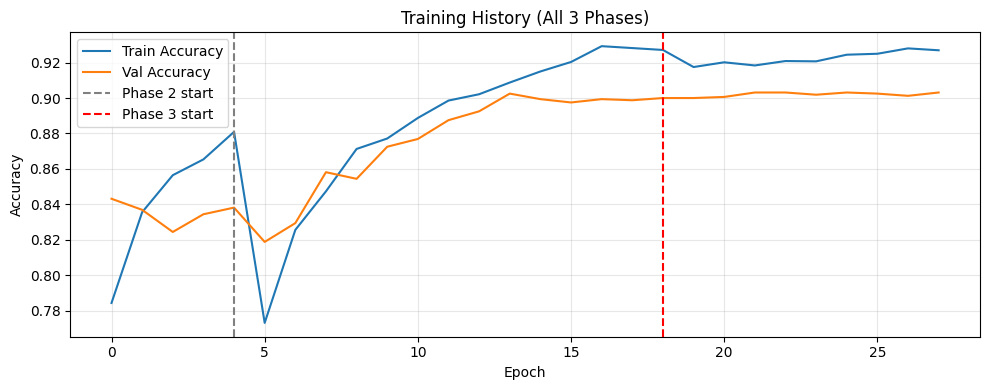

In [61]:
# Combine all 3 phases
acc  = h1.history['accuracy']  + h2.history['accuracy']  + h3.history['accuracy']
vacc = h1.history['val_accuracy'] + h2.history['val_accuracy'] + h3.history['val_accuracy']

plt.figure(figsize=(10, 4))
plt.plot(acc,  label='Train Accuracy')
plt.plot(vacc, label='Val Accuracy')
plt.axvline(len(h1.history['accuracy'])-1,                           color='gray', linestyle='--', label='Phase 2 start')
plt.axvline(len(h1.history['accuracy'])+len(h2.history['accuracy'])-1, color='red', linestyle='--', label='Phase 3 start')
plt.title('Training History (All 3 Phases)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

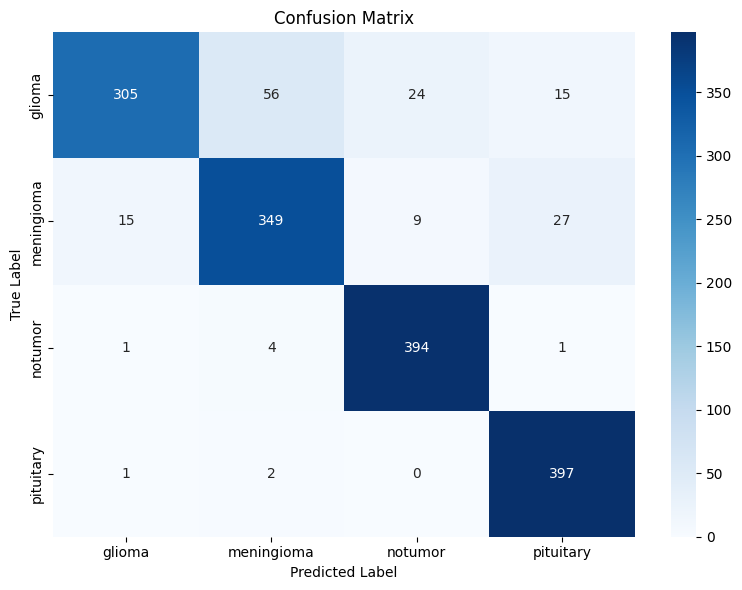

              precision    recall  f1-score   support

      glioma       0.95      0.76      0.84       400
  meningioma       0.85      0.87      0.86       400
     notumor       0.92      0.98      0.95       400
   pituitary       0.90      0.99      0.95       400

    accuracy                           0.90      1600
   macro avg       0.91      0.90      0.90      1600
weighted avg       0.91      0.90      0.90      1600



In [63]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']  # adjust if order is different

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Detailed report
print(classification_report(y_true, y_pred, target_names=class_names))

In [73]:
# Save the final model to Google Drive so it persists after Colab session ends
model.save("/content/drive/MyDrive/brain_tumor_model.keras")
print("Model saved!")

Model saved!


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf

model = tf.keras.models.load_model("/content/drive/MyDrive/brain_tumor_model.keras")
print("Model loaded!")
model.summary()

Mounted at /content/drive
Model loaded!


Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_33 (InputLayer)     │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_10 (Sequential)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,478,221 (97.19 MB)

 Trainable params: 7,147,020 (27.26 MB)

 Non-trainable params: 4,037,159 (15.40 MB)

 Optimizer params: 14,294,042 (54.53 MB)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
True Label : glioma
Image Path : /kaggle/input/brain-tumor-mri-dataset/Testing/glioma/Te-gl_186.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted Class: glioma


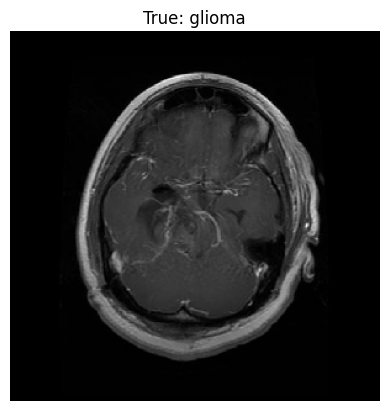

In [2]:
import random
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import kagglehub
import numpy as np

path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

# Load the trained model
model = tf.keras.models.load_model("/content/drive/MyDrive/brain_tumor_model.keras")

# Define class names, as they were determined during dataset loading
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

def predict_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(300, 300))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create a batch

    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    predicted_class = class_names[np.argmax(score)]
    print(f"Predicted Class: {predicted_class}")

# Pick a random class, then a random image from that class
test_dir = path + "/Testing"

random_class = random.choice(os.listdir(test_dir))
random_image = random.choice(os.listdir(os.path.join(test_dir, random_class)))
img_path = os.path.join(test_dir, random_class, random_image)

print(f"True Label : {random_class}")
print(f"Image Path : {img_path}")

# Predict
predict_image(img_path)

# Show the image
img = tf.keras.utils.load_img(img_path, target_size=(300, 300))
plt.imshow(img)
plt.title(f"True: {random_class}")
plt.axis('off')
plt.show()